In [20]:
import os
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent.parent
DATA_PATH = PROJECT_ROOT / "data"

print(PROJECT_ROOT)

/home/letung/Law-RAG-Chatbot


In [6]:
content_df = pl.read_parquet(DATA_PATH / "data" / "content.parquet")
metadata_df = pl.read_parquet(DATA_PATH / "data" / "metadata.parquet")
relationships_df = pl.scan_parquet(DATA_PATH / "data" / "relationships.parquet")

In [4]:
print("Content columns: \n")
for col in content_df.columns:
    print(col)

print("-"*50)
print("Metadata columns: \n")
for col in metadata_df.columns:
    print(col)
print("-"*50)
print("Relationship columns: \n")
for col in relationships_df.columns:
    print(col)


Content columns: 

id
content_html
--------------------------------------------------
Metadata columns: 

id
title
so_ky_hieu
ngay_ban_hanh
loai_van_ban
ngay_co_hieu_luc
ngay_het_hieu_luc
nguon_thu_thap
ngay_dang_cong_bao
nganh
linh_vuc
co_quan_ban_hanh
chuc_danh
nguoi_ky
pham_vi
thong_tin_ap_dung
tinh_trang_hieu_luc
--------------------------------------------------
Relationship columns: 

doc_id
other_doc_id
relationship


/tmp/ipykernel_28313/782564469.py:2: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  for col in content_df.columns:
/tmp/ipykernel_28313/782564469.py:7: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  for col in metadata_df.columns:
/tmp/ipykernel_28313/782564469.py:11: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  for col in relationships_df.columns:


In [5]:
print(content_df.schema)
print(metadata_df.schema)

Schema({'id': String, 'content_html': String})
Schema({'id': Int64, 'title': String, 'so_ky_hieu': String, 'ngay_ban_hanh': String, 'loai_van_ban': String, 'ngay_co_hieu_luc': String, 'ngay_het_hieu_luc': String, 'nguon_thu_thap': String, 'ngay_dang_cong_bao': String, 'nganh': String, 'linh_vuc': String, 'co_quan_ban_hanh': String, 'chuc_danh': String, 'nguoi_ky': String, 'pham_vi': String, 'thong_tin_ap_dung': Float64, 'tinh_trang_hieu_luc': String})


In [14]:
example = content_df.item(1, "content_html")

print(example)

<table class="detailcontent" width="100%" border="0" id="content">
                <tr>
                    <td colspan="3">
                        <div align="justify">
                            <p>
	
</p>
<p>
	
</p>
<p>
	</p><title></title>

<p align="CENTER">
	<b><font face="Times New Roman">CHỈ THỊ CỦA UBND TỈNH LÂM ĐỒNG </font></b></p>
<p align="CENTER">
	<b><font face="Times New Roman">Về việc tăng cường công tác quản lý nhà, đất và </font></b></p>
<p align="CENTER">
	<b><font face="Times New Roman">xây dựng cơ bản của các tôn giáo trong tỉnh Lâm Đồng</font></b></p>
<p align="JUSTIFY">
	<font face="Times New Roman">Trong những năm qua, thực hiện chủ trương đổi mới của Đảng và Nhà nước nói chung cũng như thực hiện chính sách tự do tín ngưỡng, tôn giáo nói riêng, chính quyền các cấp trong tỉnh đã tạo điều kiện thuận lợi đảm bảo cho các hoạt động tôn giáo, nhất là trong việc hành đạo, góp phần tích cực trong việc xây dựng, phát triển kinh tế - xã hội ở địa phương, thực hiện được 

## 1. Độ dài trung bình của các content html

shape: (1, 4)
┌──────┬────────┬─────┬────────┐
│ Mean ┆ Median ┆ Min ┆ Max    │
│ ---  ┆ ---    ┆ --- ┆ ---    │
│ i32  ┆ i32    ┆ u32 ┆ u32    │
╞══════╪════════╪═════╪════════╡
│ 2649 ┆ 1037   ┆ 14  ┆ 363721 │
└──────┴────────┴─────┴────────┘


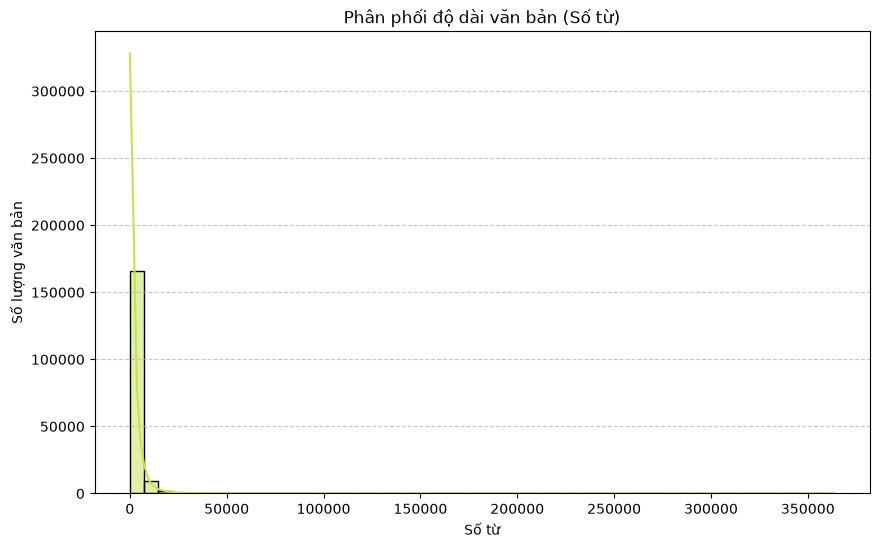

In [18]:
df = content_df.with_columns(
    pl.col("content_html").str.count_matches(r"\s+").add(1).alias("word_count")
)

print(df.select([
    pl.col("word_count").mean().cast(pl.Int32).alias("Mean"),
    pl.col("word_count").median().cast(pl.Int32).alias("Median"),
    pl.col("word_count").min().alias("Min"),
    pl.col("word_count").max().alias("Max")
]))

plt.figure(figsize=(10, 6))
sns.histplot(df["word_count"].to_numpy(), bins=50, kde=True, color="#c5e252")
plt.title("Phân phối độ dài văn bản (Số từ)")
plt.xlabel("Số từ")
plt.ylabel("Số lượng văn bản")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Tỷ lệ rác vs văn bản thật

In [21]:
def extract_text_len(html_str):
    if not html_str: return 0
    return len(BeautifulSoup(html_str, "html.parser").get_text(strip=True))

df_eda = content_df.with_columns([
    pl.col("content_html").str.len_chars().alias("html_len"),
    pl.col("content_html").map_elements(extract_text_len, return_dtype=pl.Int32).alias("text_len"),
    pl.col("content_html").str.count_matches(r"(?i)<table").alias("table_count"),
    pl.col("content_html").str.count_matches(r"(?i)<font").alias("font_count"),
    pl.col("content_html").str.count_matches(r"(?i)<script").alias("script_count")
]).with_columns(
    ((pl.col("html_len") - pl.col("text_len")) / pl.col("html_len") * 100).round(2).alias("noise_percent")
)

print(df_eda.select([
    pl.col("noise_percent").mean().alias("Mean Noise (%)"),
    pl.col("noise_percent").max().alias("Max Noise (%)"),
    pl.col("table_count").sum().alias("Total <table> tags"),
    pl.col("font_count").sum().alias("Total <font> tags")
]))

shape: (1, 4)
┌────────────────┬───────────────┬────────────────────┬───────────────────┐
│ Mean Noise (%) ┆ Max Noise (%) ┆ Total <table> tags ┆ Total <font> tags │
│ ---            ┆ ---           ┆ ---                ┆ ---               │
│ f64            ┆ f64           ┆ u32                ┆ u32               │
╞════════════════╪═══════════════╪════════════════════╪═══════════════════╡
│ 43.00187       ┆ 100.0         ┆ 332282             ┆ 2852808           │
└────────────────┴───────────────┴────────────────────┴───────────────────┘


## 3. Cấu trúc lặp lại (Structural Patterns)

In [ ]:
df_eda = df_eda.with_columns([
    pl.col("content_html").str.count_matches(r"(?i)Điều\s+\d+").alias("dieu_count"),
    pl.col("content_html").str.count_matches(r"(?i)Chương\s+[IVX]+").alias("chuong_count")
])

print(df_eda.select([
    pl.col("dieu_count").mean().round(1).alias("Avg 'Điều' / file"),
    pl.col("chuong_count").mean().round(1).alias("Avg 'Chương' / file"),
    (pl.col("chuong_count") > 0).sum().alias("Total files containing 'Chương'")
]))

abnormal_files = df_eda.filter(pl.col("noise_percent") > 80)

shape: (1, 3)
┌───────────────────┬─────────────────────┬─────────────────────────────────┐
│ Avg 'Điều' / file ┆ Avg 'Chương' / file ┆ Total files containing 'Chương… │
│ ---               ┆ ---                 ┆ ---                             │
│ f64               ┆ f64                 ┆ u32                             │
╞═══════════════════╪═════════════════════╪═════════════════════════════════╡
│ 9.6               ┆ 0.8                 ┆ 29923                           │
└───────────────────┴─────────────────────┴─────────────────────────────────┘


: 